In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/raw/bank-full.csv', sep=';')
print(f"data shape: {df.shape}")
print(df.head())

data shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [2]:
os.makedirs('results/figures/eda/', exist_ok=True)
os.makedirs('data/processed/', exist_ok=True)

cat_cols = df.select_dtypes(include=['object']).columns
print("=== Unknown value statistics ===")
for col in cat_cols:
    unknown_cnt = (df[col] == 'unknown').sum()
    print(f"{col}: {unknown_cnt} ({unknown_cnt/len(df)*100:.1f}%)")

df_clean = df.copy()
for col in cat_cols:
    df_clean[col] = df_clean[col].replace('unknown', 'missing')
df_clean.to_csv('data/processed/bankclean.csv', index=False)
print("✅ clean completed: data/processed/bankclean.csv")

=== Unknown value statistics ===
job: 288 (0.6%)
marital: 0 (0.0%)
education: 1857 (4.1%)
default: 0 (0.0%)
housing: 0 (0.0%)
loan: 0 (0.0%)
contact: 13020 (28.8%)
month: 0 (0.0%)
poutcome: 36959 (81.7%)
y: 0 (0.0%)
✅ clean completed: data/processed/bankclean.csv


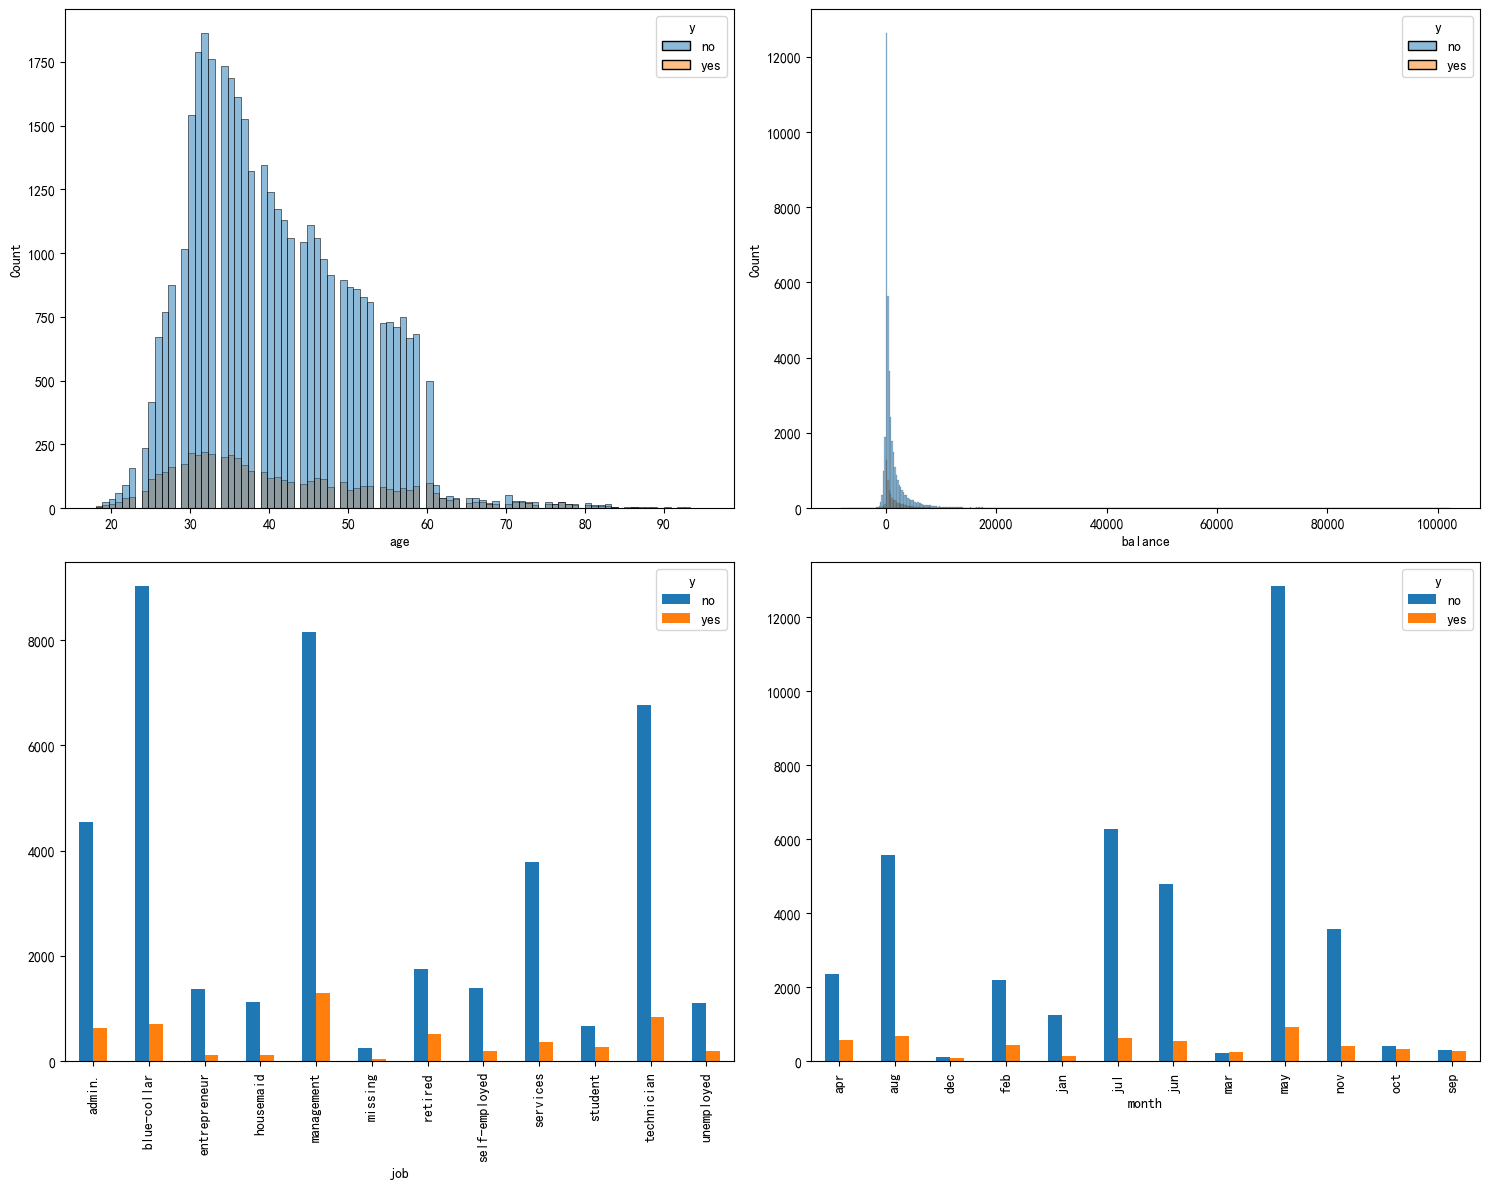

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
sns.histplot(data=df_clean, x='age', hue='y', ax=axes[0,0])
sns.histplot(data=df_clean, x='balance', hue='y', ax=axes[0,1])
df_clean.groupby('job')['y'].value_counts().unstack().plot(kind='bar', ax=axes[1,0])
df_clean.groupby('month')['y'].value_counts().unstack().plot(kind='bar', ax=axes[1,1])
plt.tight_layout()
plt.savefig('results/figures/eda/eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

=== class imbalance ===
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


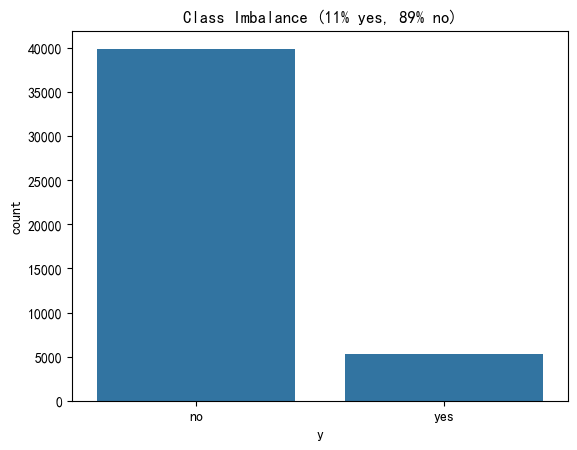

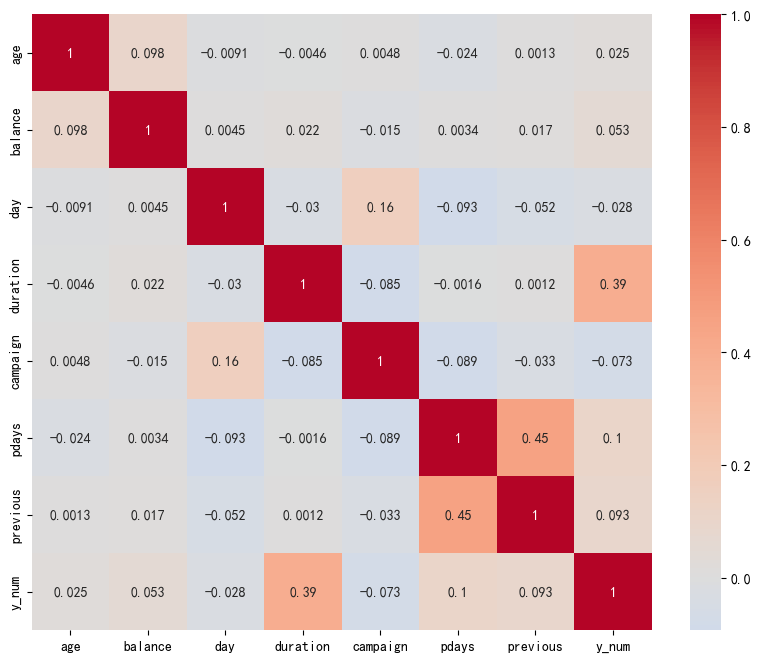

In [4]:
print("=== class imbalance ===")
print(df_clean['y'].value_counts(normalize=True))
sns.countplot(data=df_clean, x='y')
plt.title('Class Imbalance (11% yes, 89% no)')
plt.savefig('results/figures/eda/class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
df_clean['y_num'] = (df_clean['y'] == 'yes').astype(int)
corr = df_clean[num_cols + ['y_num']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.savefig('results/figures/eda/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
df_eng = df_clean.copy()
df_eng['isretired'] = (df_eng['age'] >= 65).astype(int)
df_eng['isstudent'] = (df_eng['job'] == 'student').astype(int)
df_eng['balance_per_call'] = np.where(df_eng['duration'] > 0, 
                                     df_eng['balance'] / df_eng['duration'], 0)
df_eng = pd.get_dummies(df_eng, columns=['month'], prefix='month', drop_first=True)
print("✅ New feature creation：isretired, isstudent, balance_per_call, month dummies")

✅ New feature creation：isretired, isstudent, balance_per_call, month dummies


In [6]:
X = df_eng.drop('y', axis=1)
y = df_eng['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    stratify=y, random_state=42)

train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

train.to_csv('data/processed/banktrain.csv', index=False)
test.to_csv('data/processed/banktest.csv', index=False)
print("✅ Split completed：")
print(f"train: {train.shape}, yes%: {train['y'].value_counts(normalize=True)['yes']:.1%}")
print(f"test: {test.shape}, yes%: {test['y'].value_counts(normalize=True)['yes']:.1%}")

✅ Split completed：
train: (36168, 31), yes%: 11.7%
test: (9043, 31), yes%: 11.7%


In [7]:
train_s1 = train
train_s2 = train.drop('duration', axis=1, errors='ignore')
s3_cols = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
train_s3 = train[s3_cols + ['y']].copy()
s4_cols = ['pdays', 'previous', 'poutcome']
train_s4 = train[s4_cols + ['y']].copy()

train_s1.to_csv('data/processed/train_s1.csv', index=False)
train_s2.to_csv('data/processed/train_s2.csv', index=False)
train_s3.to_csv('data/processed/train_s3.csv', index=False)
train_s4.to_csv('data/processed/train_s4.csv', index=False)

print("✅ 4-Scene Dataset Completed：train_s1.csv, s2.csv, s3.csv, s4.csv")

✅ 4-Scene Dataset Completed：train_s1.csv, s2.csv, s3.csv, s4.csv


In [ ]:
# === FIX: 修正train/test split格式 (Member2反馈) ===
from sklearn.model_selection import train_test_split
import os

X = df_eng.drop('y', axis=1)
y = df_eng['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

train_corrected = X_train.copy()
train_corrected['y'] = y_train
test_features = X_test.copy()
test_target = y_test.to_frame(name='y')

train_corrected.to_csv('data/processed/train.csv', index=False)
test_features.to_csv('data/processed/test_features.csv', index=False)
test_target.to_csv('data/processed/test_target.csv', index=False)

print("✅ Member2格式修正完成：")
print(f"train.csv: {train_corrected.shape} (features+y)")
print(f"test_features.csv: {test_features.shape} (features only!)")
print(f"test_target.csv: {test_target.shape} (y only)")

✅ Member2格式修正完成：
train.csv: (36168, 31) (features+y)
test_features.csv: (9043, 30) (features only!)
test_target.csv: (9043, 1) (y only)
